In [ ]:
from __future__ import annotations
from dataclasses import dataclass
from pathlib import Path
from typing import Tuple
import numpy as np
import matplotlib.pyplot as plt
import imageio.v3 as iio
import tifffile as tiff
from PIL import Image
from IPython.display import display
from scipy.ndimage import gaussian_filter


In [28]:



def find_project_root(start: Path | None = None) -> Path:
    """Find nearest parent containing 'pictures' folder."""
    p = (start or Path.cwd()).resolve()
    for cur in [p, *p.parents]:
        if (cur / "pictures").exists():
            return cur
    return p

print (find_project_root())
def read_image_any(path: Path) -> np.ndarray: #将图片变成numpy数组
    """Read .tif/.tiff via tifffile; other formats via imageio."""
    path = Path(path)
    ext = path.suffix.lower()
    if ext in {".tif", ".tiff"}:
        img = tiff.imread(str(path))
    else:
        img = iio.imread(path)

    img = np.asarray(img)
    if img.ndim == 3 and img.shape[-1] == 4:  # RGBA -> RGB
        img = img[..., :3]
    return img


def _to_float01(img: np.ndarray) -> np.ndarray: # 将图片数据转换为0-1范围的浮点数
    img = np.asarray(img)
    if img.ndim == 2:
        img = np.stack([img, img, img], axis=-1)
    if img.ndim == 3 and img.shape[-1] == 4:
        img = img[..., :3]
    if img.ndim != 3 or img.shape[-1] != 3:
        raise ValueError(f"Expect RGB image, got {img.shape}")

    if np.issubdtype(img.dtype, np.floating): # 如果已经是浮点数类型，检查是否需要缩放
        x = img.astype(np.float32, copy=False)
        if np.nanmax(x) > 1.0:
            x = x / 255.0
    else:
        x = img.astype(np.float32) / 255.0
    return np.clip(x, 0.0, 1.0)

def _to_uint8(img01: np.ndarray) -> np.ndarray: # 将0-1范围的浮点数图像转换回0-255范围的uint8格式
    return (np.clip(img01, 0.0, 1.0) * 255.0 + 0.5).astype(np.uint8)

def save_png(img: np.ndarray, out_path: Path) -> None: # 将图像保存为PNG格式
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    iio.imwrite(str(out_path), img, extension=".png")

import numpy as np

def slider_c(val: float) -> float:
    """val in [-100,100] -> c in [-1,1]"""
    return float(np.clip(val, -100, 100) / 100.0)

def slider_factor(val: float) -> float:
    """val in [-100,100] -> factor in [0,2]"""
    c = slider_c(val)
    return float(np.clip(1.0 + c, 0.0, 2.0))
def rgb_to_luma(img01: np.ndarray) -> np.ndarray:
    return (0.2126 * img01[..., 0] +
            0.7152 * img01[..., 1] +
            0.0722 * img01[..., 2])
def adjust_clarity_luma(img01: np.ndarray, clarity: float, sigma: float = 2.0) -> np.ndarray:
    """
    Clarity on luminance only (no color halos).
    clarity: [-100,100]
    sigma: 控制作用尺度（1~3 常用；越大越“粗”）
    """
    c = slider_c(clarity)  # [-1,1]

    L = rgb_to_luma(img01)                      # (H,W)
    L_blur = gaussian_filter(L, sigma=sigma)    # (H,W)
    L2 = np.clip(L + c * (L - L_blur), 0.0, 1.0)

    # 保持色相：按亮度比例缩放RGB
    eps = 1e-6
    ratio = (L2 + eps) / (L + eps)              # (H,W)
    out = img01 * ratio[..., None]
    return np.clip(out, 0.0, 1.0)

def adjust_brightness(img01: np.ndarray, brightness: float) -> np.ndarray:
    """
    Brightness 用乘法增益（统一 factor 规则）：
    factor=0 -> 全黑
    factor=1 -> 不变
    factor=2 -> 变亮（近似“加倍”）
    """
    f = slider_factor(brightness)
    return np.clip(img01 * f, 0.0, 1.0)
def adjust_highlights(img01: np.ndarray, highlights: float) -> np.ndarray:
    """
    Highlights 用“向白色收缩/远离”（统一 factor 规则）：
    factor=0 -> 纯白
    factor=1 -> 不变
    factor=2 -> 高光增强
    """
    f = slider_factor(highlights)
    out = img01 + (1.0 - img01) * (f - 1.0)
    return np.clip(out, 0.0, 1.0)

def adjust_contrast(img01: np.ndarray, contrast: float) -> np.ndarray:
    """
    Contrast 围绕 0.5 拉伸/压缩（统一 factor 规则）：
    factor=0 -> 全部变 0.5（中灰）
    factor=1 -> 不变
    factor=2 -> 对比增强
    """
    f = slider_factor(contrast)
    return np.clip((img01 - 0.5) * f + 0.5, 0.0, 1.0)

def adjust_saturation(img01: np.ndarray, saturation: float) -> np.ndarray:
    """
    Saturation 用“向灰度收缩/远离”（统一 factor 规则）：
    factor=0 -> 纯灰度
    factor=1 -> 不变
    factor=2 -> 饱和度增强
    """
    f = slider_factor(saturation)
    luma = (0.2126 * img01[..., 0] + 0.7152 * img01[..., 1] + 0.0722 * img01[..., 2])[..., None]
    out = luma + (img01 - luma) * f
    return np.clip(out, 0.0, 1.0)

def adjust_warmth(img01: np.ndarray, warmth: float) -> np.ndarray:
    """
    Warmth：用同一个 c 推出“红增益”和“蓝增益（互补）”
    c in [-1,1]
    r_factor = clip(1+c, 0,2)
    b_factor = clip(1-c, 0,2) = 2 - r_factor

    warmth=+100 -> c=+1 -> R*2, B*0 (更暖)
    warmth=0    -> c=0  -> R*1, B*1 (不变)
    warmth=-100 -> c=-1 -> R*0, B*2 (更冷)
    """
    c = slider_c(warmth)
    r_factor = float(np.clip(1.0 + c, 0.0, 2.0))
    b_factor = float(np.clip(1.0 - c, 0.0, 2.0))

    out = img01.copy()
    out[..., 0] = np.clip(out[..., 0] * r_factor, 0.0, 1.0)  # R
    out[..., 2] = np.clip(out[..., 2] * b_factor, 0.0, 1.0)  # B
    return out

def apply_sliders(img: np.ndarray, clarity=0, brightness=0, contrast=0, saturation=0, highlights=0, warmth=0, debug=False):
    x = _to_float01(img)
    x = adjust_clarity_luma(x, clarity=clarity, sigma=2.0)
    x = adjust_brightness(x, brightness)
    x = adjust_contrast(x, contrast)
    x = adjust_highlights(x, highlights)
    x = adjust_saturation(x, saturation)
    x = adjust_warmth(x, warmth)
    return x


C:\Users\qq187\OneDrive\文档\project\cancer-1


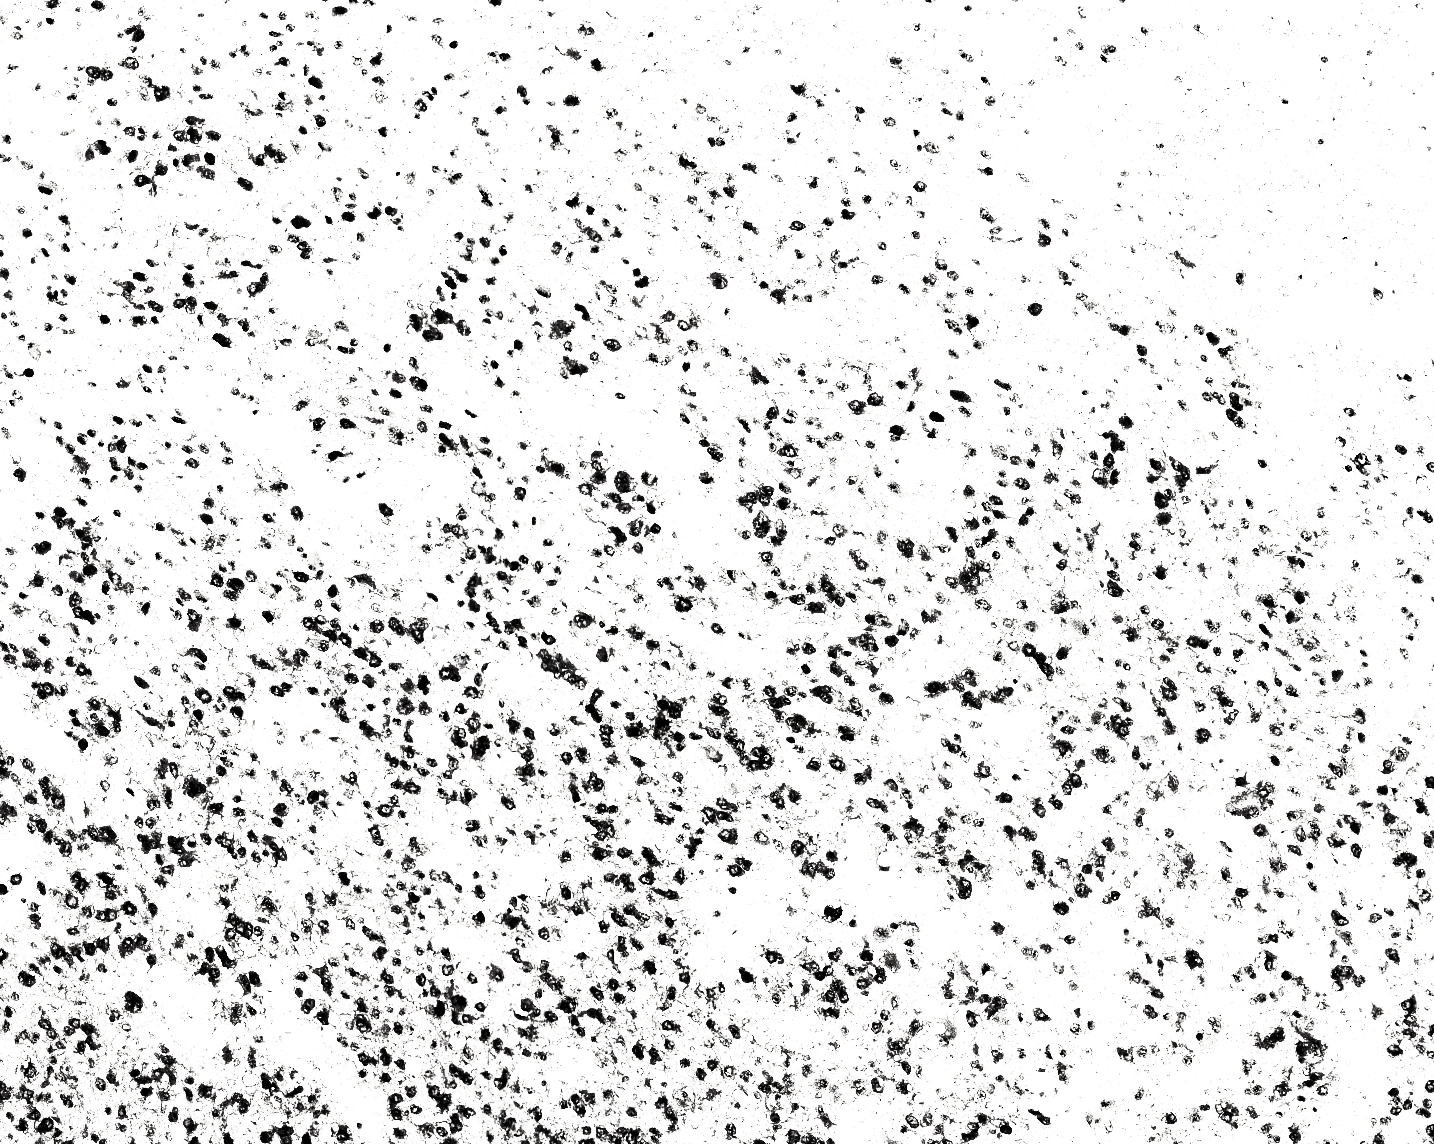

saved: C:\Users\qq187\OneDrive\文档\project\cancer-1\pictures\260558_1 (1)_bcst.png


In [ ]:
#test the code's effectiveness



root = find_project_root()
in_path = root / "pictures"/ "260558_1 (1).tif"
img = read_image_any(in_path)

out = apply_sliders(
    img,
    clarity=-22,      # -100..100
    brightness=70, 
    highlights=-100,   # -100..100
    contrast=99,
    saturation=-99,
    warmth=0
)

display(Image.fromarray(_to_uint8(out)))   # out 必须是 uint8 RGB
out_path = root / "pictures" / f"{in_path.stem}_bcst.png"
save_png(_to_uint8(out), out_path)
print("saved:", out_path)